<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-2-Distribution-Learning/Untitled150.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Heisenberg Distribution**

The Heisenberg distribution in $R^3$ is spanned by two vector fields
$$X_1 = \partial_{x_1} + 2 x_2 \partial_{x_3} = (1, 0, 2x_2), \quad X_2 = \partial_{x_2} - 2 x_1 \partial_{x_3} = (0, 1, -2x_1).$$
Use Python to draw these fields in $R^3$ in a neighborhood of the origin. Use red color for $X_1$ and blue for $X_2$.


<>:31: SyntaxWarning: invalid escape sequence '\,'
<>:31: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipython-input-1607342175.py:31: SyntaxWarning: invalid escape sequence '\,'
  'Vector field $X_1 =  (1,\,0,\,2x_2) $',


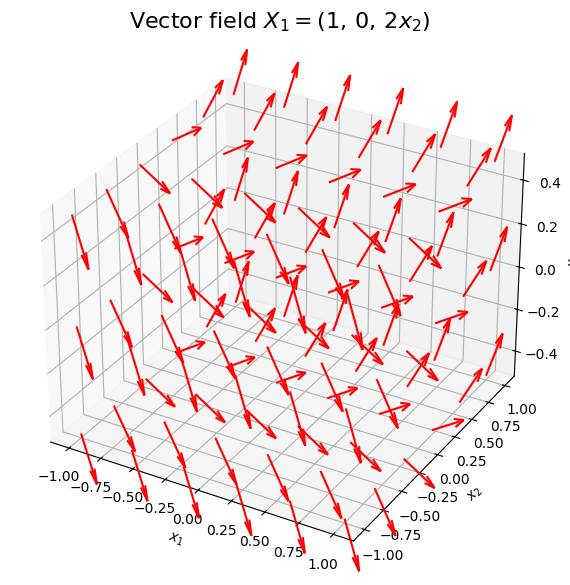

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create a grid around the origin
x1 = np.linspace(-1, 1, 6)
x2 = np.linspace(-1, 1, 6)
x3 = np.linspace(-0.5, 0.5, 3)  # thin slab

X1, X2, X3 = np.meshgrid(x1, x2, x3)

# Define the Heisenberg vector fields
U1 = np.ones_like(X1)
V1 = np.zeros_like(X2)
W1 = 2 * X2

U2 = np.zeros_like(X1)
V2 = np.ones_like(X2)
W2 = -2 * X1

# Plot
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

ax.quiver(X1, X2, X3, U1, V1, W1, color='red', length=0.25, normalize=True)
#ax.quiver(X1, X2, X3, U2, V2, W2, color='blue', length=0.2, normalize=True)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$x_3$')
ax.set_title(
    'Vector field $X_1 =  (1,\,0,\,2x_2) $',
    fontsize=16
)


plt.show()


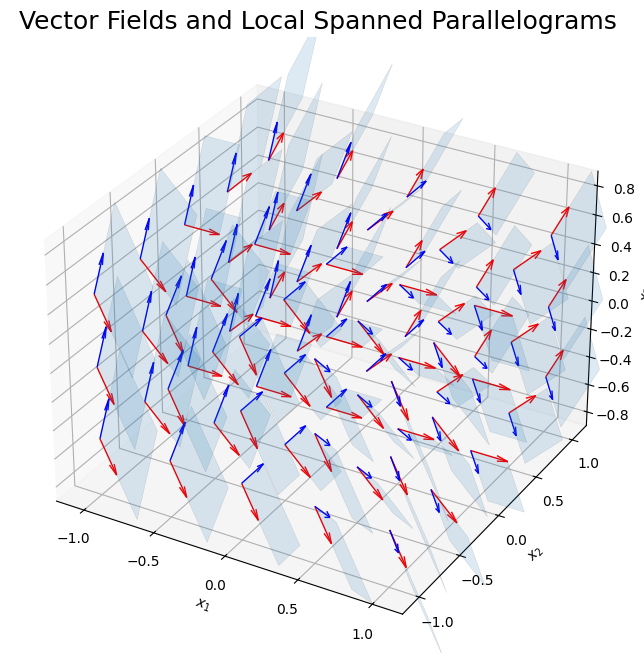

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Grid around the origin (fewer points to keep the plot readable)
x1 = np.linspace(-1, 1, 5)
x2 = np.linspace(-1, 1, 5)
x3 = np.linspace(-0.5, 0.5, 3)  # thin slab

X1g, X2g, X3g = np.meshgrid(x1, x2, x3, indexing='xy')

# Heisenberg vector fields at each grid point
V1 = np.stack([
    np.ones_like(X1g),
    np.zeros_like(X2g),
    2 * X2g
], axis=-1)

V2 = np.stack([
    np.zeros_like(X1g),
    np.ones_like(X2g),
    -2 * X1g
], axis=-1)

# Scale vectors for visualization of the parallelograms
scale = 0.25
V1s = scale * V1
V2s = scale * V2

# Flatten for plotting
P = np.stack([X1g, X2g, X3g], axis=-1).reshape(-1, 3)
V1f = V1.reshape(-1, 3)
V2f = V2.reshape(-1, 3)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Draw vector fields
ax.quiver(P[:, 0], P[:, 1], P[:, 2], V1f[:, 0], V1f[:, 1], V1f[:, 2],
          color='red', length=0.25, normalize=True, linewidth=1)
ax.quiver(P[:, 0], P[:, 1], P[:, 2], V2f[:, 0], V2f[:, 1], V2f[:, 2],
          color='blue', length=0.25, normalize=True, linewidth=1)

# Draw the parallelogram spanned by X1, X2 at each point
polys = []
for p, a, b in zip(P, V1s.reshape(-1, 3), V2s.reshape(-1, 3)):
    p0 = p
    p1 = p + a
    p2 = p + b
    p3 = p + a + b
    polys.append([p0, p1, p3, p2])

poly_collection = Poly3DCollection(polys, alpha=0.15, edgecolor='k', linewidths=0.3)
ax.add_collection3d(poly_collection)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$x_3$')
ax.set_title(
    'Vector Fields and Local Spanned Parallelograms',
    fontsize=18)


ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_zlim(-0.9, 0.9)

plt.show()


# **Geodesics**

The next code draws the sub-Riemannian geodesic between (0,0,0) and (0, 0, 1) and computes the associated CC-distance.

epoch 1 | loss 100.076019 | length 0.0801240057 | hor 0.999958932
epoch 500 | loss 1.8853122 | length 1.79434395 | hor 0.000909682713
epoch 1000 | loss 1.81344962 | length 1.80022061 | hor 0.000132290283
epoch 1500 | loss 1.80194557 | length 1.79280055 | hor 9.145066e-05
epoch 2000 | loss 1.79336667 | length 1.78530109 | hor 8.06561657e-05
epoch 2500 | loss 1.78339481 | length 1.77680337 | hor 6.59138e-05
epoch 3000 | loss 1.77534854 | length 1.7717272 | hor 3.62136052e-05
epoch 3500 | loss 1.77338886 | length 1.77049279 | hor 2.89603468e-05
epoch 4000 | loss 1.77280605 | length 1.77022433 | hor 2.58171149e-05
epoch 4500 | loss 1.77420366 | length 1.76768959 | hor 6.51408263e-05
epoch 5000 | loss 1.77210665 | length 1.76982427 | hor 2.28242625e-05
epoch 5500 | loss 1.77188325 | length 1.769678 | hor 2.20519923e-05
epoch 6000 | loss 1.77187264 | length 1.76861835 | hor 3.25428882e-05


/tmp/ipython-input-4161794822.py:108: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  length = np.trapz(speed, t_np)


Learned length ≈ 1.7706428  | true √π ≈ 1.7724538509055159


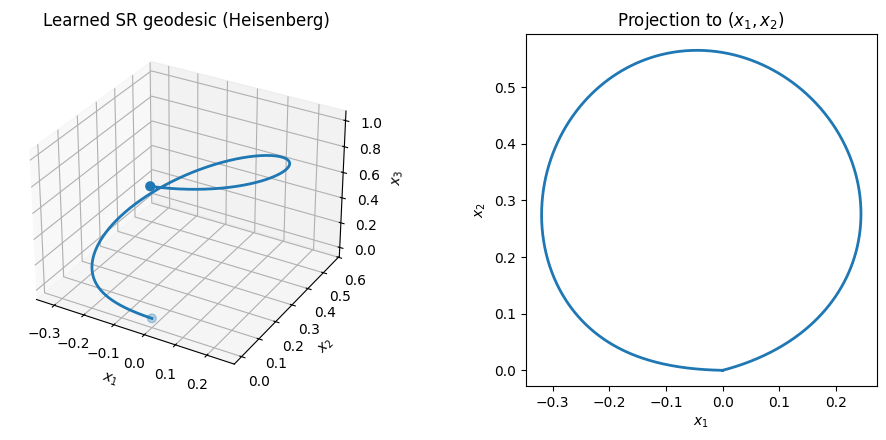

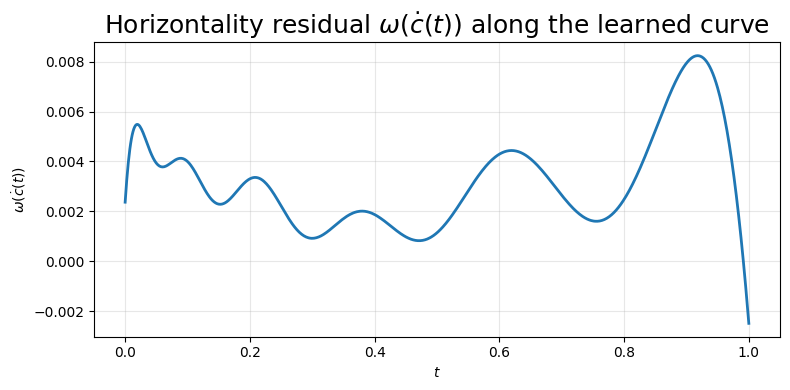

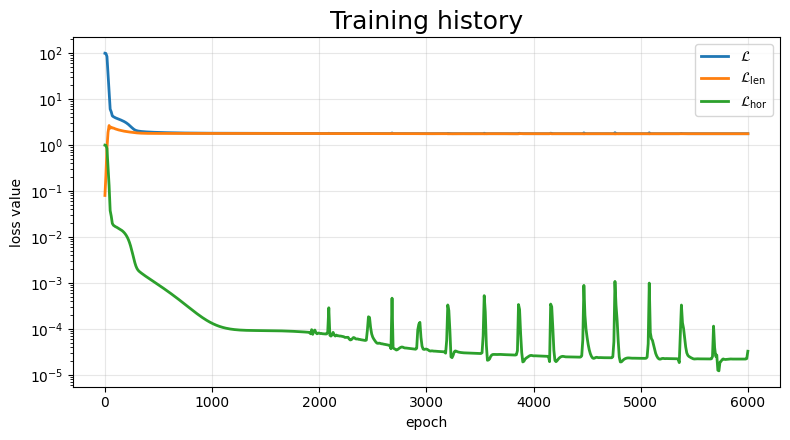

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ===== Problem setup =====
T = 1.0
qA = tf.constant([0.0, 0.0, 0.0], dtype=tf.float32)
qB = tf.constant([0.0, 0.0, 1.0], dtype=tf.float32)

Nc = 400
lam = 100.0
epochs = 6000
lr = 1e-3
log_every = 10

t = tf.linspace(0.0, T, Nc)[:, None]   # (Nc,1)

# ===== Neural network =====
net = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(3)
])

opt = tf.keras.optimizers.Adam(lr)

def curve(theta_t):
    """
    Hard-embed endpoints: c(0)=qA, c(T)=qB.
    """
    s = theta_t / T
    base = (1.0 - s) * qA + s * qB               # (Nc,3)
    corr = s * (1.0 - s) * net(s)                # (Nc,3)
    return base + corr

def trapz(y, x):
    dx = x[1:] - x[:-1]
    return tf.reduce_sum(0.5 * (y[1:] + y[:-1]) * dx)

@tf.function
def train_step():
    with tf.GradientTape() as tape:
        with tf.GradientTape() as tape_t:
            tape_t.watch(t)
            c = curve(t)                          # (Nc,3)

        dc = tape_t.batch_jacobian(c, t)          # (Nc,3,1)
        dc = tf.squeeze(dc, axis=-1)              # (Nc,3)

        x1, x2, x3 = c[:, 0], c[:, 1], c[:, 2]
        dx1, dx2, dx3 = dc[:, 0], dc[:, 1], dc[:, 2]

        # SR speed for orthonormal frame {X1, X2}
        speed = tf.sqrt(dx1*dx1 + dx2*dx2 + 1e-12)

        # Horizontality residual: omega(dot c)
        omega = dx3 + 2.0*x1*dx2 - 2.0*x2*dx1

        L_len = trapz(speed, tf.squeeze(t))
        L_hor = trapz(omega*omega, tf.squeeze(t))

        loss = L_len + lam * L_hor

    grads = tape.gradient(loss, net.trainable_variables)
    opt.apply_gradients(zip(grads, net.trainable_variables))
    return loss, L_len, L_hor

# ===== Training =====
log_epochs = []
log_loss = []
log_len = []
log_hor = []

for ep in range(1, epochs + 1):
    loss, L_len, L_hor = train_step()

    if ep % 500 == 0 or ep == 1:
        tf.print("epoch", ep, "| loss", loss, "| length", L_len, "| hor", L_hor)

    if ep % log_every == 0 or ep == 1:
        log_epochs.append(ep)
        log_loss.append(float(loss))
        log_len.append(float(L_len))
        log_hor.append(float(L_hor))

# ===== Evaluate & plot =====
t_eval = tf.linspace(0.0, T, 800)[:, None]
with tf.GradientTape() as tape_t:
    tape_t.watch(t_eval)
    c_eval = curve(t_eval)

dc_eval = tape_t.batch_jacobian(c_eval, t_eval)
dc_eval = tf.squeeze(dc_eval, axis=-1)

x1 = c_eval[:, 0].numpy()
x2 = c_eval[:, 1].numpy()
x3 = c_eval[:, 2].numpy()

dx1 = dc_eval[:, 0].numpy()
dx2 = dc_eval[:, 1].numpy()
dx3 = dc_eval[:, 2].numpy()

t_np = t_eval[:, 0].numpy()

speed = np.sqrt(dx1**2 + dx2**2)
length = np.trapz(speed, t_np)

omega = dx3 + 2.0*x1*dx2 - 2.0*x2*dx1

print("Learned length ≈", length, " | true √π ≈", np.sqrt(np.pi))

# ===== Plot 1: trajectory and xy-projection =====
fig = plt.figure(figsize=(10, 4.5))

ax = fig.add_subplot(121, projection="3d")
ax.plot(x1, x2, x3, linewidth=2)
ax.scatter([0, 0], [0, 0], [0, 1], s=40)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$x_3$")
ax.set_title("Learned SR geodesic (Heisenberg)")

ax2 = fig.add_subplot(122)
ax2.plot(x1, x2, linewidth=2)
ax2.set_aspect("equal", "box")
ax2.set_xlabel("$x_1$")
ax2.set_ylabel("$x_2$")
ax2.set_title("Projection to $(x_1,x_2)$")

plt.tight_layout()
plt.show()

# ===== Plot 2: horizontality residual omega(dot c(t)) =====
plt.figure(figsize=(8, 4))
plt.plot(t_np, omega, linewidth=2)
plt.xlabel("$t$")
plt.ylabel(r"$\omega(\dot c(t))$")
plt.title(r"Horizontality residual $\omega(\dot c(t))$ along the learned curve",fontsize=18)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===== Plot 3: loss vs epochs =====
plt.figure(figsize=(8, 4.5))
plt.plot(log_epochs, log_loss, label=r"${\cal L}$", linewidth=2)
plt.plot(log_epochs, log_len, label=r"${\cal L}_{\rm len}$", linewidth=2)
plt.plot(log_epochs, log_hor, label=r"${\cal L}_{\rm hor}$", linewidth=2)
plt.xlabel("epoch")
plt.ylabel("loss value")
plt.yscale("log")
plt.title("Training history", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
